# Колоквиум 2
*Вариант №1*

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## 1. Опишите теоретическую модель линейной и логистической регрессии.

Task: $Y = A(X)$
- $Y$ - output data
- $X$ - input data (входные данные)
- $A$ - function

Aproximate the task:
1. **Linear Regression**:
    - $y \in \mathbb{R}$
    - $\vec x \in \mathbb{R}^n, n \in \mathbb{N}$
    - $y = \sum_{i=0}^n\omega_i x_i$, where $\vec\omega \in \mathbb{R}^n$
$$
\omega_{n+1} = \omega_n - \alpha \frac{1}{m} \sum_{i=0}^{m-1} ((\vec\omega,X^{(i)}) - Y^{(i)})
$$
2. **Logic Classification**:
    - $y \in \{-1, 1\}$
    - $\vec x \in \mathbb{R}^n, n \in \mathbb{N}$
    - $y = f(\sum_{i=0}^n\omega_i x_i) > b$, where $\vec\omega \in \mathbb{R}^n, b \in \mathbb{R}, f$ - some function
$$\omega_{n+1} = \omega_{n} - \alpha \frac{1}{m} X(f(\omega, X)-Y)^{T},$$

In [18]:
class LinearRegression():

    def __init__(self, learning_rate, iterations) -> None:
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.b = None

    def fit(self, X: np.ndarray, Y: np.ndarray, step: int=1e2) -> None:
        self.weights = np.zeros(X.shape[1])
        self.b = 0

        for i in tqdm(range(self.iterations), desc=f"MSE: {self.MSE(self.predict(X), Y)}"):
            self.update_weights(X, Y)

    def update_weights(self, X: np.ndarray, Y: np.ndarray) -> None:
        F = self.predict(X)
        m = X.shape[0]
        self.weights -= self.lr * (1 / m) * np.dot(X.T, (F - Y))
        self.b -= self.lr * (1 / m) * np.sum(F - Y)

    def predict(self, X: np.ndarray) -> float:
        return np.sum(self.weights * X, axis=1) + self.b
    
    @staticmethod
    def MSE(X: np.ndarray, Y: np.ndarray) -> float:
        if X.shape != Y.shape:
            raise Exception(f"X shape: {X.shape} != Y shape: {Y.shape}")
        return (1 / (2 * X.shape[0])) * sum((X - Y)**2)


class LogisticRegression:
    from typing import Self
    def __init__(self) -> None:
        self.w = None

    def fit(self, X: np.ndarray, y: np.ndarray, n_iterations: int, eta: float) -> list[float]:
        from tqdm import tqdm
        self.w = np.zeros((X.shape[0], 1))
        losses = []
        pbar = tqdm(range(n_iterations), desc=f"Loss: {np.inf}")
        for _ in pbar:
            loss, grad = self.log_loss(X, y)
            self.w -= eta * grad
            losses.append(loss)
            pbar.set_description(f"Loss: {loss:.4f}")
        return losses

    def log_loss(self, X: np.ndarray, y: np.ndarray) -> tuple[np.float64, np.ndarray]:
        p = self.sigmoid(self.w.T @ X)
        loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        grad = (1 / X.shape[1]) * (X @ (p - y).T)

        return loss, grad

    def predict(self, X: np.ndarray, b: float=0.5) -> np.ndarray:
        probs = self.sigmoid(self.w.T @ X)
        y_predicted = np.where(probs > b, 1, 0)
        return y_predicted

    def fit_predict(self, X: np.ndarray, y: np.ndarray, n_iterations: int, eta: float, b: float=0.5) -> np.ndarray:
        self.fit(X, y, n_iterations, eta)
        return self.predict(X, b)

    @staticmethod
    def sigmoid(x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

## 2. Напишите следующий код: сгенерируйте данные в виде набора точек по нескольким кластерам; выполните кластеризацию; визуализируйте результат.

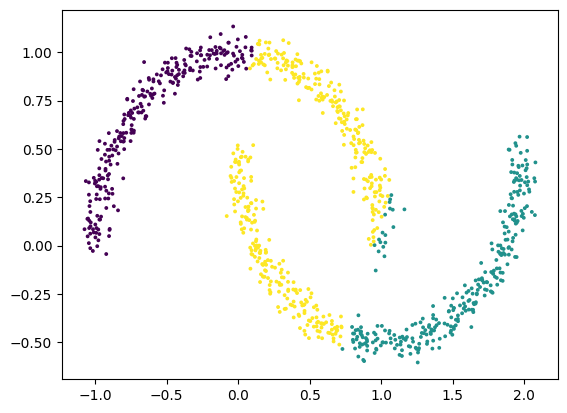

In [19]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

data = make_moons(n_samples=1000, noise=0.05, random_state=0)[0]
predict = KMeans(n_clusters=3, random_state=0).fit_predict(data)
plt.scatter(data[:, 0], data[:, 1], c=predict, s=3);

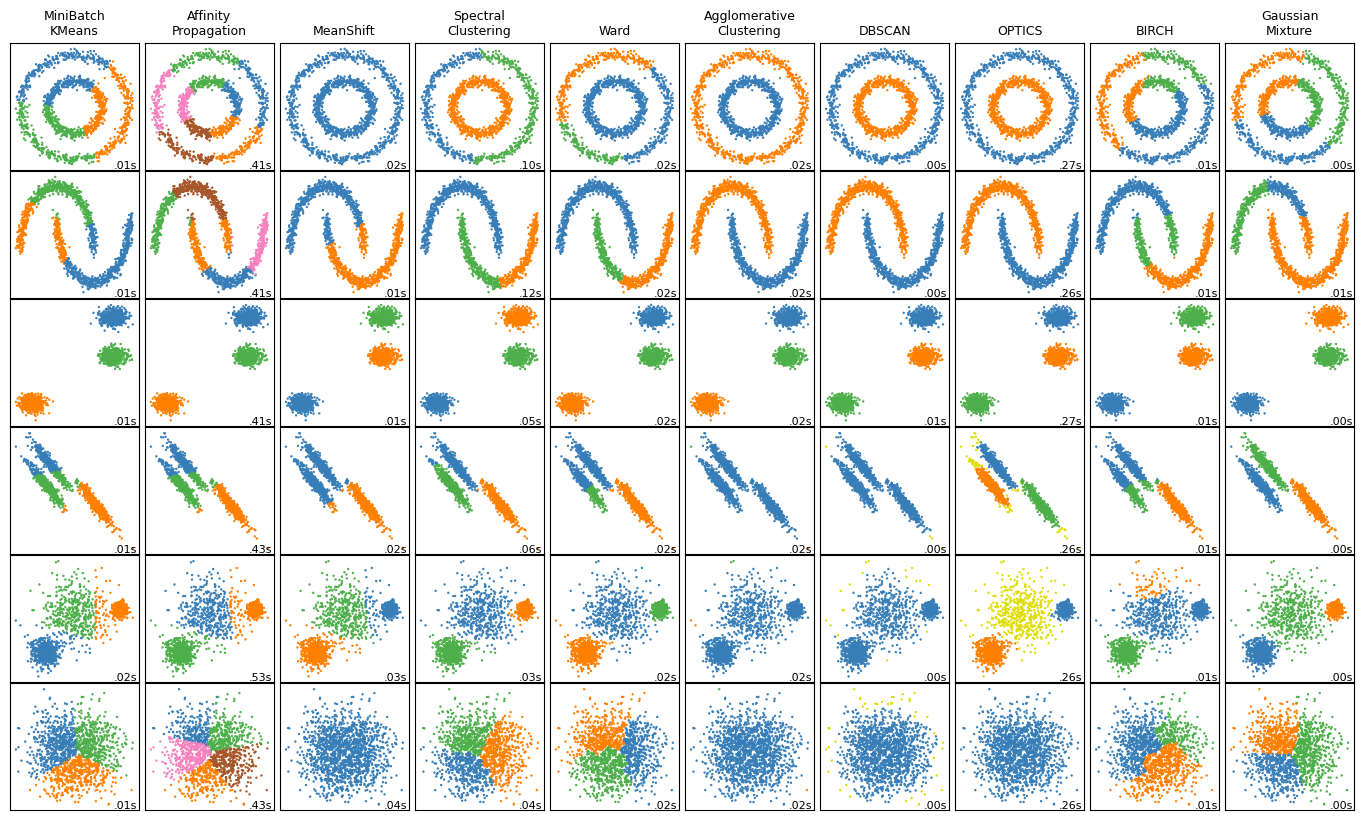

In [20]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn import datasets

# Optional (HDBSCAN)
try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False

np.random.seed(0)

# ============
# Generate datasets
# ============
n_samples = 1500

noisy_circles = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05
)  # already noisy [web:12]
noisy_moons = datasets.make_moons(
    n_samples=n_samples, noise=0.05
)  # already noisy [web:12]
blobs = datasets.make_blobs(
    n_samples=n_samples, random_state=8
)  # base blobs [web:12]

# anisotropic blobs
random_state = 170
X_aniso, y_aniso = datasets.make_blobs(
    n_samples=n_samples, random_state=random_state
)  # [web:12]
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X_aniso, transformation)
aniso = (X_aniso, y_aniso)

# blobs with varied variances = different density
varied = datasets.make_blobs(
    n_samples=n_samples,
    cluster_std=[1.0, 2.5, 0.5],  # different std → density difference [web:9][web:12]
    random_state=random_state,
)

# extra noisy dataset (uniform noise + Gaussian noise)
uniform_noise = np.random.rand(n_samples, 2)
gauss_noise = uniform_noise + 0.25 * np.random.randn(n_samples, 2)

datasets_list = [
    noisy_circles,
    noisy_moons,
    blobs,
    aniso,
    varied,
    (gauss_noise, None),
]

# ============
# Define clustering algorithms
# ============
default_base = {
    "quantile": .3,
    "eps": .3,
    "damping": .9,
    "preference": -200,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

plt.figure(figsize=(14, 8))
plt.subplots_adjust(left=.02, right=.98, bottom=.001, top=.96, wspace=.05,
                    hspace=.01)

plot_num = 1

for i_dataset, (X, y) in enumerate(datasets_list):
    X = StandardScaler().fit_transform(X)

    # estimate bandwidth for MeanShift
    ms_bandwidth = cluster.estimate_bandwidth(X, quantile=default_base["quantile"])

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=default_base["n_neighbors"], include_self=False)
    connectivity = 0.5 * (connectivity + connectivity.T)

    # List of clustering algorithms
    two_means = cluster.MiniBatchKMeans(
        n_clusters=default_base["n_clusters"])
    affinity_propagation = cluster.AffinityPropagation(
        damping=default_base["damping"],
        preference=default_base["preference"],
        random_state=0)
    ms = cluster.MeanShift(bandwidth=ms_bandwidth, bin_seeding=True)
    spectral = cluster.SpectralClustering(
        n_clusters=default_base["n_clusters"], eigen_solver='arpack',
        affinity="nearest_neighbors", random_state=0)
    ward = cluster.AgglomerativeClustering(
        n_clusters=default_base["n_clusters"], linkage='ward',
        connectivity=connectivity)
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average",
        n_clusters=default_base["n_clusters"],
        connectivity=connectivity)
    dbscan = cluster.DBSCAN(eps=default_base["eps"])
    optics = cluster.OPTICS(
        min_samples=default_base["min_samples"],
        xi=default_base["xi"],
        min_cluster_size=default_base["min_cluster_size"])
    birch = cluster.Birch(
        n_clusters=default_base["n_clusters"])
    gmm = mixture.GaussianMixture(
        n_components=default_base["n_clusters"],
        covariance_type='full')

    clustering_algorithms = [
        ("MiniBatch\nKMeans", two_means),
        ("Affinity\nPropagation", affinity_propagation),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("DBSCAN", dbscan),
        ("OPTICS", optics),
        ("BIRCH", birch),
        ("Gaussian\nMixture", gmm),
    ]

    if HAS_HDBSCAN:
        clustering_algorithms.insert(
            8, ("HDBSCAN", hdbscan.HDBSCAN(
                min_samples=default_base["min_samples"],
                min_cluster_size=int(default_base["min_cluster_size"] * len(X)))))

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")

            if name == "Gaussian\nMixture":
                algorithm.fit(X)
                y_pred = algorithm.predict(X)
            else:
                algorithm.fit(X)
                if hasattr(algorithm, 'labels_'):
                    y_pred = algorithm.labels_.astype(int)
                else:
                    y_pred = algorithm.predict(X)

        t1 = time.time()
        colors = np.array(['#377eb8', '#ff7f00', '#4daf4a',
                           '#f781bf', '#a65628', '#984ea3',
                           '#999999', '#e41a1c', '#dede00'])

        plt.subplot(len(datasets_list), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, fontsize=9)
        plt.scatter(X[:, 0], X[:, 1], s=0.5, color=colors[y_pred % len(colors)])
        plt.xticks(())
        plt.yticks(())
        plt.text(0.99, 0.01, ('%.2fs' % (t1 - t0)).lstrip('0'),
                 transform=plt.gca().transAxes, size=8,
                 horizontalalignment='right')
        plot_num += 1

plt.show()


## 3. Опишите метрику для проверки качества алгоритмов классификации.

[Заходим](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)

- **Accuracy**: $$\frac1{|y|}(tp(y)+ tn)(y)$$
- **Precision**: $$\frac{tp(y)}{tp(y) + fp(y)}$$
- **Recall**: $$\frac{tp(y)}{tp(y) + fn(y)}$$
- **f1-score**: $$\frac{2tp(y)}{2tp(y) + fp(y) + fn(y)}$$
- **log loss**: $$-(tp(y)log(b) + (1 -tp(y))log(1 - b))$$
- **roc_auc**: $$\sum_{i=1}^{n-1} (\text{FPR}_{i+1} - \text{FPR}_i)\,\frac{\text{TPR}_{i+1} + \text{TPR}_i}{2}$$
$$\text{TPR} = \frac{TP}{TP+FN}$$
$$\text{FPR} = \frac{FP}{FP+TN}$$
